# PANGA EDA → xarray NetCDF (header-aware)

This notebook:
- Summarizes the **download manifest**
- Reads PANGA files
- combine components
- Filters to stations with **>5 years** of data within **2010 → present**
- Builds a **provider-specific NetCDF** (UNR) compatible with xarray

Constraints:
- Displacements and sigmas in **meters**
- Station metadata limited to **lat, lon, alt_m**


In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pandas.core.dtypes.common import pandas_dtype

plt.rcParams["figure.dpi"] = 140


## 1) Inputs

Set these paths to your local folders.

In [2]:
DATA_DIR = Path("./data/panga_daily_cleaned")  # directory containing *.tenv3
MANIFEST = Path("./outputs/panga/manifest.csv")  # produced by downloader

assert DATA_DIR.exists(), f"Missing {DATA_DIR.resolve()}"
assert MANIFEST.exists(), f"Missing {MANIFEST.resolve()}"
print("OK:", DATA_DIR, MANIFEST)


OK: data\panga_daily_cleaned outputs\panga\manifest.csv


## 2) Manifest summary

In [3]:
manifest = pd.read_csv(MANIFEST)
display(manifest.head())

print(f"Total files: {len(manifest)} stations: {len(manifest) / 3}")
print(manifest["status"].value_counts() / 3)


,station,component,url,status,http_status,bytes,path,error
0,ABBY,lat,https://www.panga.org/cgi-bin/timeseries_data....,failed,NaN,NaN,NaN,HTTPError('500 Server Error: Internal Server E...
1,ABBY,lon,https://www.panga.org/cgi-bin/timeseries_data....,failed,NaN,NaN,NaN,HTTPError('500 Server Error: Internal Server E...
2,ABBY,rad,https://www.panga.org/cgi-bin/timeseries_data....,failed,NaN,NaN,NaN,HTTPError('500 Server Error: Internal Server E...
3,ABOT,lat,https://www.panga.org/cgi-bin/timeseries_data....,failed,NaN,NaN,NaN,HTTPError('500 Server Error: Internal Server E...
4,ABOT,lon,https://www.panga.org/cgi-bin/timeseries_data....,failed,NaN,NaN,NaN,HTTPError('500 Server Error: Internal Server E...


Total files: 1812 stations: 604.0
status
downloaded    422.0
failed        182.0
Name: count, dtype: float64


## 3) read panga files

In [4]:
PANGA_COMP_TO_AXIS = {
    "lon": "east",
    "lat": "north",
    "rad": "up",
}

def find_panga_data_start_line(path: Path) -> int:
    """
    Returns the 0-based line index where numeric data begins (first row after the table header).
    Looks for the table header line containing 'T' and 'RESIDUALS' and 'SIG_RESID'.
    """
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for i, raw in enumerate(f):
            line = raw.strip()
            if line.startswith("#") and "T" in line and "RESIDUAL" in line and "SIG" in line:
                return i + 1  # data starts on next line
    raise ValueError(f"Could not find data table header in {path}")


def read_panga_dqrfit_member(
        base_dir: Path,
        station_id: str,
        component: str,
) -> pd.DataFrame:
    """
    Read one PANGA DQRFIT residual file given:
      - base_dir (folder containing the files)
      - station_id (e.g. 'AGNS')
      - component ('lon' | 'lat' | 'rad')

    Expected filename:
      {station_id}.{component}.txt
    """
    base_dir = Path(base_dir)
    path = base_dir / f"{station_id}.{component}.txt"
    if not path.exists():
        raise FileNotFoundError(path)

    start = find_panga_data_start_line(path)

    df = pd.read_csv(
        path,
        sep=r"\s+",
        engine="python",
        skiprows=start,
        comment="#",
        header=None,
        names=["dec_year", "residual_mm", "sigma_mm"],
    )

    for c in ["dec_year", "residual_mm", "sigma_mm"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["dec_year", "residual_mm"]).reset_index(drop=True)
    df["station"] = station_id
    df["component"] = component
    return df

def read_panga_station_dqrfit(
    base_dir: Path,
    station_id: str,
) -> pd.DataFrame:
    """
    Read lon/lat/rad DQRFIT residuals for one station and return
    a single dataframe with consistent column naming:

      dec_year
      east_m, north_m, up_m
      east_sigma_m, north_sigma_m, up_sigma_m
    """
    base_dir = Path(base_dir)

    dfs = []

    for comp, axis in PANGA_COMP_TO_AXIS.items():
        dfc = read_panga_dqrfit_member(
            base_dir=base_dir,
            station_id=station_id,
            component=comp,
        )

        # rename + unit conversion
        dfc = dfc.rename(
            columns={
                "residual_mm": f"{axis}_m",
                "sigma_mm": f"{axis}_sigma_m",
            }
        )

        dfc[f"{axis}_m"] *= 1e-3
        dfc[f"{axis}_sigma_m"] *= 1e-3

        dfs.append(
            dfc[["dec_year", f"{axis}_m", f"{axis}_sigma_m"]]
        )

    # outer join on time to survive missing epochs
    out = dfs[0]
    for dfc in dfs[1:]:
        out = out.merge(dfc, on="dec_year", how="outer")

    out = out.sort_values("dec_year").reset_index(drop=True)
    out["station"] = station_id

    return out

## 4) Inspect one station

In [5]:
stat = "ALBH"
component = "lat"

raw = read_panga_station_dqrfit(DATA_DIR, stat)
raw

,dec_year,east_m,east_sigma_m,north_m,north_sigma_m,up_m,up_sigma_m,station
0,1996.00000,0.002306,0.002023,0.002872,0.001650,-0.002598,0.006034,ALBH
1,1996.00273,0.001407,0.002010,0.001569,0.001650,-0.002500,0.006034,ALBH
2,1996.00547,0.001436,0.002030,0.000756,0.001647,0.003722,0.006049,ALBH
3,1996.00821,0.002538,0.001994,0.001905,0.001629,0.005587,0.005930,ALBH
4,1996.01095,0.002676,0.001985,0.000462,0.001619,-0.000652,0.005886,ALBH
...,...,...,...,...,...,...,...,...
10914,2025.93566,-0.002170,0.001698,0.000162,0.001383,0.001626,0.005099,ALBH
10915,2025.93839,-0.001569,0.001702,0.001027,0.001385,0.001172,0.005107,ALBH
10916,2025.94113,-0.002581,0.001676,0.000328,0.001378,0.001029,0.005028,ALBH
10917,2025.94661,-0.001549,0.001723,0.001382,0.001406,0.001366,0.005168,ALBH


#### verification plot

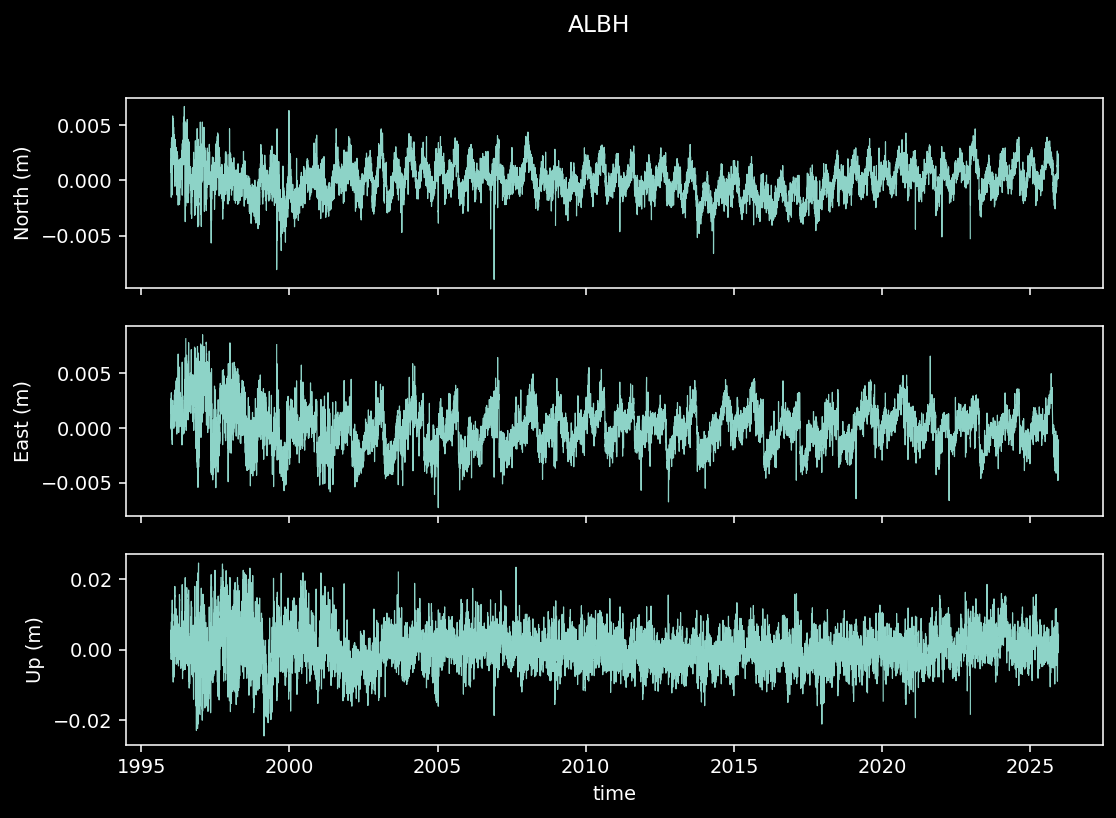

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

ax[0].plot(raw.dec_year, raw.north_m, lw=0.6)
ax[0].set_ylabel("North (m)")

ax[1].plot(raw.dec_year, raw.east_m, lw=0.6)
ax[1].set_ylabel("East (m)")

ax[2].plot(raw.dec_year, raw.up_m, lw=0.6)
ax[2].set_ylabel("Up (m)")
ax[2].set_xlabel("time")

plt.suptitle(stat)
plt.show()


## 5) Apply filters: 2010→present and >5 years

In [7]:
station_list = pd.read_csv("./resources/catalog_subset_bbox.csv")
station_list

,name,lat,lon,elev_m
0,ABBY,49.072141,-122.197803,195.280394
1,ABOT,49.029436,-122.266570,-4.009165
2,AGNS,42.552765,-124.059114,51.368366
3,AL2H,48.389780,-123.487472,31.750396
4,ALB4,48.389740,-123.487687,30.890637
...,...,...,...,...
599,YCS2,46.941249,-122.590563,91.426696
600,YELM,46.948717,-122.605735,81.993392
601,YOCR,45.379102,-121.743553,1884.269527
602,YONC,43.634111,-123.298301,86.491947


In [8]:
START_YEAR = 2010.0
END_YEAR = 2025 + 1
MIN_YEARS = 5.0


def filter_window(ts: pd.DataFrame) -> pd.DataFrame:
    return ts[(ts.dec_year >= START_YEAR) & (ts.dec_year <= END_YEAR)].copy()


def has_min_span(ts: pd.DataFrame, min_years: float = MIN_YEARS) -> bool:
    if ts.empty:
        return False
    return float(ts.dec_year.max() - ts.dec_year.min()) >= float(min_years)


ts_by_station = {}
fail = []  # (station, filename, error)
missing_on_disk = []  # stations listed in CSV but file not found

for st in station_list.name.astype(str).str.strip().str.lower().tolist():
    p = DATA_DIR / f"{st}.lat.txt"  # adjust if .enu etc
    if not p.exists():
        missing_on_disk.append(st)
        continue
    try:
        ts = read_panga_station_dqrfit(DATA_DIR, st)
        ts = filter_window(ts)

        if has_min_span(ts):
            ts_by_station[st] = ts
        else:
            fail.append((st, p.name, f"Span < {MIN_YEARS}y after filtering"))
    except Exception as e:
        fail.append((st, p.name, str(e)))

valid_stations = sorted(ts_by_station.keys())
print(f"Valid stations loaded: {len(valid_stations)}")
print(f"Missing on disk: {len(missing_on_disk)}")
print(f"Failed (parse/filter/span): {len(fail)}")


Valid stations loaded: 372
Missing on disk: 182
Failed (parse/filter/span): 50


In [9]:
if missing_on_disk:
    print("\n--- Missing on disk (first 50) ---")
    for s in missing_on_disk[:50]:
        print(" ", s)

if fail:
    print("\n--- Failed (first 20) ---")
    for st, fname, err in fail[:20]:
        print(f" {st} ({fname}): {err}")



--- Missing on disk (first 50) ---
  abby
  abot
  al2h
  alb4
  aldr
  bcab
  bcbu
  bcch
  bcco
  bccq
  bccr
  bccy
  bcdn
  bcdt
  bcho
  bclg
  bcnn
  bcpm
  bcsc
  bcsk
  bcsq
  bcts
  bcut
  bcvi
  bcvt
  bcws
  blnp
  c046
  ca1r
  cacc
  cach
  cacr
  cacy
  caeu
  cafl
  cafm
  cams
  cawi
  cayk
  cbrv
  ccrt
  cedr
  chco
  chw2
  cmbr
  cme6
  cobi
  copm
  coqu
  cot3

--- Failed (first 20) ---
 agns (agns.lat.txt): Span < 5.0y after filtering
 blvu (blvu.lat.txt): Span < 5.0y after filtering
 brnb (brnb.lat.txt): Span < 5.0y after filtering
 bton (bton.lat.txt): Span < 5.0y after filtering
 cami (cami.lat.txt): Span < 5.0y after filtering
 chst (chst.lat.txt): Span < 5.0y after filtering
 coan (coan.lat.txt): Span < 5.0y after filtering
 crbn (crbn.lat.txt): Span < 5.0y after filtering
 cshr (cshr.lat.txt): Span < 5.0y after filtering
 dea2 (dea2.lat.txt): Span < 5.0y after filtering
 dowl (dowl.lat.txt): Span < 5.0y after filtering
 dwh1 (dwh1.lat.txt): Span < 5.0y aft

In [12]:
ts_by_station

{'albh':          dec_year    east_m  east_sigma_m   north_m  north_sigma_m      up_m  \
 5105   2010.00136  0.002280      0.001772  0.002326       0.001470  0.004696   
 5106   2010.00410  0.001616      0.001760  0.001988       0.001458 -0.000385   
 5107   2010.00684  0.001758      0.001754  0.001756       0.001471 -0.006803   
 5108   2010.00958  0.001697      0.001765  0.001767       0.001484  0.000955   
 5109   2010.01232  0.001456      0.001781  0.001309       0.001480 -0.001058   
 ...           ...       ...           ...       ...            ...       ...   
 10914  2025.93566 -0.002170      0.001698  0.000162       0.001383  0.001626   
 10915  2025.93839 -0.001569      0.001702  0.001027       0.001385  0.001172   
 10916  2025.94113 -0.002581      0.001676  0.000328       0.001378  0.001029   
 10917  2025.94661 -0.001549      0.001723  0.001382       0.001406  0.001366   
 10918  2025.94935 -0.001099      0.001714  0.001353       0.001399  0.003973   
 
        up_sigma_m

## 6) xarray Dataset with dims (time, station) and station coords from catalog


In [15]:
list_ds = []
fail = []

for st, tmp_df in ts_by_station.items():
    try:
        df = tmp_df.copy()

        if "station" in df.columns:
            df = df.drop(columns=["station"])

        # build time index
        df = df.set_index("dec_year").sort_index()

        # convert to xarray and add station dimension
        ds_st = df.to_xarray().expand_dims(station=[st])

        list_ds.append(ds_st)

    except Exception as e:
        fail.append((st, str(e)))

ds = xr.concat(list_ds, dim="station", join="outer").sortby("dec_year")

print(f"Stations concatenated: {ds.sizes['station']}")
print(f"Time steps (union):    {ds.sizes['dec_year']}")
if fail:
    print(f"Failed stations:       {len(fail)} (first 10 below)")
    for st, err in fail[:10]:
        print(" ", st, "->", err)

ds

Stations concatenated: 372
Time steps (union):    43492


<xarray.Dataset> Size: 777MB
Dimensions:        (station: 372, dec_year: 43492)
Coordinates:
  * station        (station) object 3kB 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
  * dec_year       (dec_year) float64 348kB 2.01e+03 2.01e+03 ... 2.026e+03
Data variables:
    east_m         (station, dec_year) float64 129MB nan 0.00228 nan ... nan nan
    east_sigma_m   (station, dec_year) float64 129MB nan 0.001772 ... nan nan
    north_m        (station, dec_year) float64 129MB nan 0.002326 ... nan nan
    north_sigma_m  (station, dec_year) float64 129MB nan 0.00147 nan ... nan nan
    up_m           (station, dec_year) float64 129MB nan 0.004696 ... nan nan
    up_sigma_m     (station, dec_year) float64 129MB nan 0.005351 ... nan nan

In [16]:
if fail:
    print(f"Failed stations:       {len(fail)} (first 10 below)")
    for st, err in fail[:10]:
        print(" ", st, "->", err)


## 7) Station coords from catalog (CSV)

In [17]:
station_list["station"] = station_list["name"].astype(str).str.strip().str.lower()
station_list = station_list.set_index("station")

station_list_aligned = station_list.reindex(ds.station.to_numpy())

ds = ds.assign_coords(
    lat=("station", station_list_aligned["lat"].to_numpy(dtype=np.float64)),
    lon=("station", station_list_aligned["lon"].to_numpy(dtype=np.float64)),
    elev_m=("station", station_list_aligned["elev_m"].to_numpy(dtype=np.float64)),
)
ds

<xarray.Dataset> Size: 777MB
Dimensions:        (station: 372, dec_year: 43492)
Coordinates:
  * station        (station) object 3kB 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
  * dec_year       (dec_year) float64 348kB 2.01e+03 2.01e+03 ... 2.026e+03
    lat            (station) float64 3kB 48.39 48.17 43.82 ... 45.38 43.63 47.29
    lon            (station) float64 3kB -123.5 -122.1 -121.4 ... -123.3 -122.2
    elev_m         (station) float64 3kB 31.77 23.29 1.509e+03 ... 86.49 82.06
Data variables:
    east_m         (station, dec_year) float64 129MB nan 0.00228 nan ... nan nan
    east_sigma_m   (station, dec_year) float64 129MB nan 0.001772 ... nan nan
    north_m        (station, dec_year) float64 129MB nan 0.002326 ... nan nan
    north_sigma_m  (station, dec_year) float64 129MB nan 0.00147 nan ... nan nan
    up_m           (station, dec_year) float64 129MB nan 0.004696 ... nan nan
    up_sigma_m     (station, dec_year) float64 129MB nan 0.005351 ... nan nan

## 8) Write NetCDF (UNR)

In [18]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_PANGA_2010_2025_5y_NA.nc"

encoding = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
ds.to_netcdf(OUT_NC, encoding=encoding)
print("Wrote:", OUT_NC)


Wrote: outputs\gnss_PANGA_2010_2025_5y_NA.nc


## 9) Smoke test: reopen and plot one station

<xarray.Dataset> Size: 777MB
Dimensions:        (station: 372, dec_year: 43492)
Coordinates:
  * station        (station) <U4 6kB 'albh' 'arli' 'asbu' ... 'yonc' 'zse1'
  * dec_year       (dec_year) float64 348kB 2.01e+03 2.01e+03 ... 2.026e+03
    lat            (station) float64 3kB ...
    lon            (station) float64 3kB ...
    elev_m         (station) float64 3kB ...
Data variables:
    east_m         (station, dec_year) float64 129MB ...
    east_sigma_m   (station, dec_year) float64 129MB ...
    north_m        (station, dec_year) float64 129MB ...
    north_sigma_m  (station, dec_year) float64 129MB ...
    up_m           (station, dec_year) float64 129MB ...
    up_sigma_m     (station, dec_year) float64 129MB ...


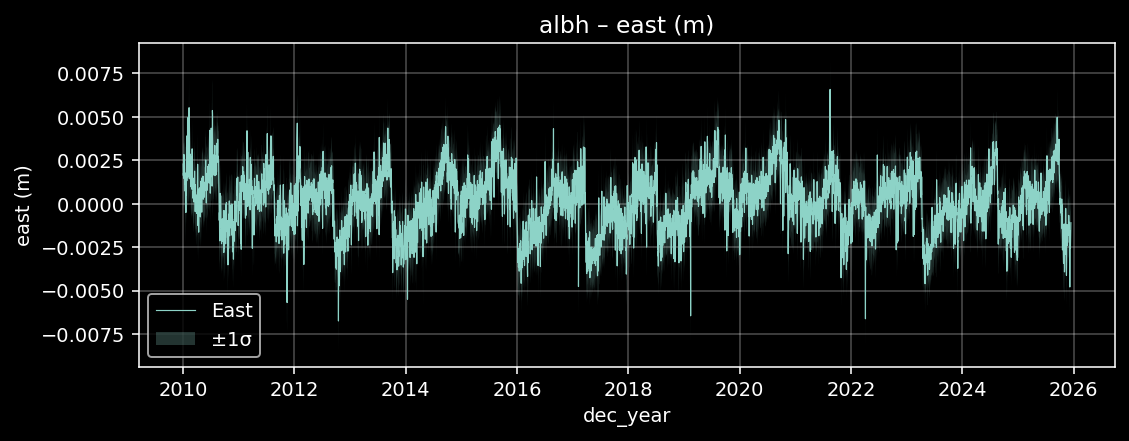

In [22]:
ds = xr.open_dataset(OUT_NC)
print(ds)

st = "albh"
sel = ds.sel(station=st).dropna(dim="dec_year", how="all")

plt.figure(figsize=(9, 3))

# central value
plt.plot(sel.dec_year, sel.east_m, lw=0.6, label="East")

# ±1σ envelope
plt.fill_between(
    sel.dec_year,
    sel.east_m - sel.east_sigma_m,
    sel.east_m + sel.east_sigma_m,
    alpha=0.25,
    linewidth=0,
    label="±1σ"
)

plt.title(f"{st} – east (m)")
plt.xlabel("dec_year")
plt.ylabel("east (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


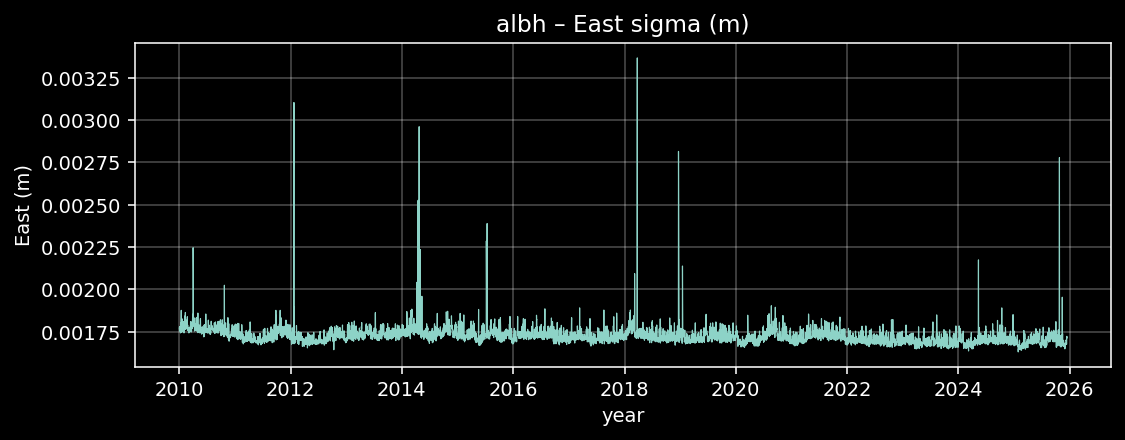

In [23]:
plt.figure(figsize=(9, 3))
plt.plot(sel.dec_year, sel.east_sigma_m, lw=0.6)
plt.title(f"{st} – East sigma (m)")
plt.xlabel("year")
plt.ylabel("East (m)")
plt.grid(True, alpha=0.3)
plt.show()

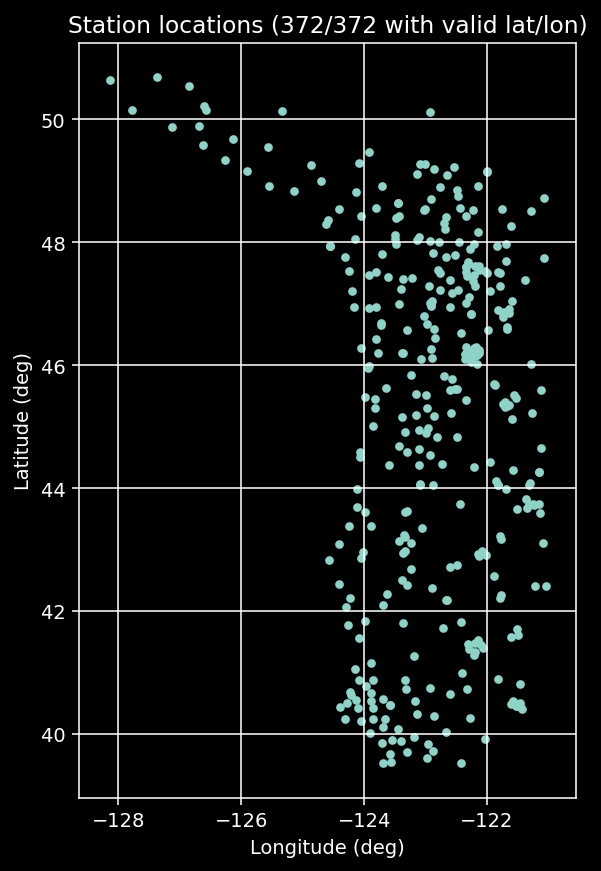

In [24]:
# --- grab station coords ---
lon = ds["lon"].values
lat = ds["lat"].values

mask = np.isfinite(lon) & np.isfinite(lat)
n_total = lon.size
n_ok = int(mask.sum())

# --- plot ---
plt.figure(figsize=(9, 7))
plt.scatter(lon[mask], lat[mask], s=12)  # (no explicit color per your style rule)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Station locations ({n_ok}/{n_total} with valid lat/lon)")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

# nice bounds with padding
if n_ok > 0:
    xmin, xmax = np.nanmin(lon[mask]), np.nanmax(lon[mask])
    ymin, ymax = np.nanmin(lat[mask]), np.nanmax(lat[mask])
    pad_x = max(0.5, 0.05 * (xmax - xmin))
    pad_y = max(0.5, 0.05 * (ymax - ymin))
    plt.xlim(xmin - pad_x, xmax + pad_x)
    plt.ylim(ymin - pad_y, ymax + pad_y)

plt.show()

In [26]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_PANGA_2010_2025_5y_NA_3stations_compact.nc"

# 1) pick first 3 stations (preserves order)
st3 = ds.station.isel(station=slice(0, 3)).values
ds3 = ds.sel(station=st3)

# 2) compact time axis: drop dec_year where *everything* is NaN for these stations
ds3 = ds3.dropna(dim="dec_year", how="all")

# 3) write compressed
encoding = {v: {"zlib": True, "complevel": 4} for v in ds3.data_vars}
ds3.to_netcdf(OUT_NC, encoding=encoding)

print("Stations:", list(st3))
print("Dims:", dict(ds3.sizes))
print("Wrote:", OUT_NC)

Stations: [np.str_('albh'), np.str_('arli'), np.str_('asbu')]
Dims: {'station': 3, 'dec_year': 6253}
Wrote: outputs\gnss_PANGA_2010_2025_5y_NA_3stations_compact.nc


In [28]:
test = xr.open_dataset(OUT_NC)
test

<xarray.Dataset> Size: 951kB
Dimensions:        (station: 3, dec_year: 6253)
Coordinates:
  * station        (station) <U4 48B 'albh' 'arli' 'asbu'
  * dec_year       (dec_year) float64 50kB 2.01e+03 2.01e+03 ... 2.026e+03
    lat            (station) float64 24B ...
    lon            (station) float64 24B ...
    elev_m         (station) float64 24B ...
Data variables:
    east_m         (station, dec_year) float64 150kB ...
    east_sigma_m   (station, dec_year) float64 150kB ...
    north_m        (station, dec_year) float64 150kB ...
    north_sigma_m  (station, dec_year) float64 150kB ...
    up_m           (station, dec_year) float64 150kB ...
    up_sigma_m     (station, dec_year) float64 150kB ...